In [1]:
import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import torch
import torch_geometric
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from graph_builder import (
    build_graph, load_all_tables,
    # ── individual node builders (import to call directly if needed) ──
    add_commit_node, add_file_nodes, add_function_nodes,
    add_developer_nodes, add_issue_nodes, add_pr_nodes, add_tag_nodes,
    # ── individual edge builders ──
    add_commit_file_edges, add_file_function_edges, add_function_comod_edges,
    add_developer_edges, add_commit_issue_edges, add_commit_pr_edges,
    add_commit_tag_edges, add_sdlc_cross_edges, add_temporal_edges,
)


/Users/tolgakuntman/miniconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
target_hash = 'a5a51ad3a1200e2e5ef46c140bab717422e41ca2'

# Graph mode
#   1 = raw features, one node per issue / PR / tag
#   2 = engineered (commit-level aggregates), single node per entity type
#   3 = hybrid: issues + PRs single engineered, tags multiple raw
#   4 = development window: 1 tag before + 1 tag after commit
MODE = 4

# Toggle entire node types on / off
INCLUDE_FILES       = True
INCLUDE_FUNCTIONS   = True
INCLUDE_DEVELOPERS  = True
INCLUDE_ISSUES      = True
INCLUDE_PRS         = True
INCLUDE_TAGS        = True

# Max raw SDLC nodes per type  (mode 1: issues/PRs/tags; mode 3: tags only)
# Set to None for no limit
MAX_ISSUES = 20
MAX_PRS    = 20
MAX_TAGS   = None

# Developer ownership filter (Bird et al. 2011)
OWNERSHIP_THRESHOLD   = 0.05
OWNERSHIP_WINDOW_DAYS = 90


In [3]:
# Load all tables once — reuse across builds
print('Loading tables …')
tables = load_all_tables('..')
for k, v in tables.items():
    shape = v.shape if v is not None else 'None'
    print(f'  {k:25s}: {shape}')


Loading tables …
  commit_info              : (8796, 21)
  file_info                : (10872, 16)
  function_info            : (12847, 15)
  ownership_window         : (269831, 16)
  developer_info           : (38007, 9)
  commit_author            : (11360, 3)
  commit_features          : (8773, 16)
  issue_info               : (691670, 10)
  pr_info                  : (469952, 13)
  release_tag_info         : (6617, 8)


In [4]:
# ── Build graph ──────────────────────────────────────────────────────
g = build_graph(
    commit_hash           = target_hash,
    tables                = tables,
    mode                  = MODE,
    include_files         = INCLUDE_FILES,
    include_functions     = INCLUDE_FUNCTIONS,
    include_developers    = INCLUDE_DEVELOPERS,
    include_issues        = INCLUDE_ISSUES,
    include_prs           = INCLUDE_PRS,
    include_tags          = INCLUDE_TAGS,
    ownership_threshold   = OWNERSHIP_THRESHOLD,
    ownership_window_days = OWNERSHIP_WINDOW_DAYS,
    max_issues            = MAX_ISSUES,
    max_prs               = MAX_PRS,
    max_tags              = MAX_TAGS,
)
print(g)

print(f"\n{'='*60}")
print(f"MODE {MODE}  |  commit: {target_hash[:12]}…")
for nt in g.node_types:
    x = g[nt].x
    print(f"  {nt:15s}: {x.shape[0]:5d} nodes  feat_dim={x.shape[1]}")
print()
for et in g.edge_types:
    ei = g[et].edge_index
    ea = g[et].get('edge_attr')
    attr_str = f'  attr={ea.shape[1]}' if ea is not None else ''
    print(f"  {str(et):55s}: {ei.shape[1]:5d} edges{attr_str}")


HeteroData(
  commit={ x=[1, 9] },
  file={ x=[2, 10] },
  function={ x=[2, 5] },
  developer={ x=[4, 4] },
  issue={ x=[1, 2] },
  pull_request={ x=[1, 2] },
  release_tag={ x=[2, 2] },
  (commit, has, file)={
    edge_index=[2, 2],
    edge_attr=[2, 10],
  },
  (file, has, function)={
    edge_index=[2, 2],
    edge_attr=[2, 6],
  },
  (function, co_modified, function)={
    edge_index=[2, 0],
    edge_attr=[0, 2],
  },
  (commit, authored_by, developer)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (developer, owns, file)={
    edge_index=[2, 7],
    edge_attr=[7, 3],
  },
  (commit, linked_issue, issue)={ edge_index=[2, 1] },
  (issue, issue_of, commit)={ edge_index=[2, 1] },
  (commit, linked_pr, pull_request)={ edge_index=[2, 1] },
  (pull_request, pr_of, commit)={ edge_index=[2, 1] },
  (commit, has_release_tag, release_tag)={
    edge_index=[2, 2],
    edge_attr=[2, 2],
  },
  (release_tag, tag_of, commit)={
    edge_index=[2, 2],
    edge_attr=[2, 2],
  },
  (pull_requ

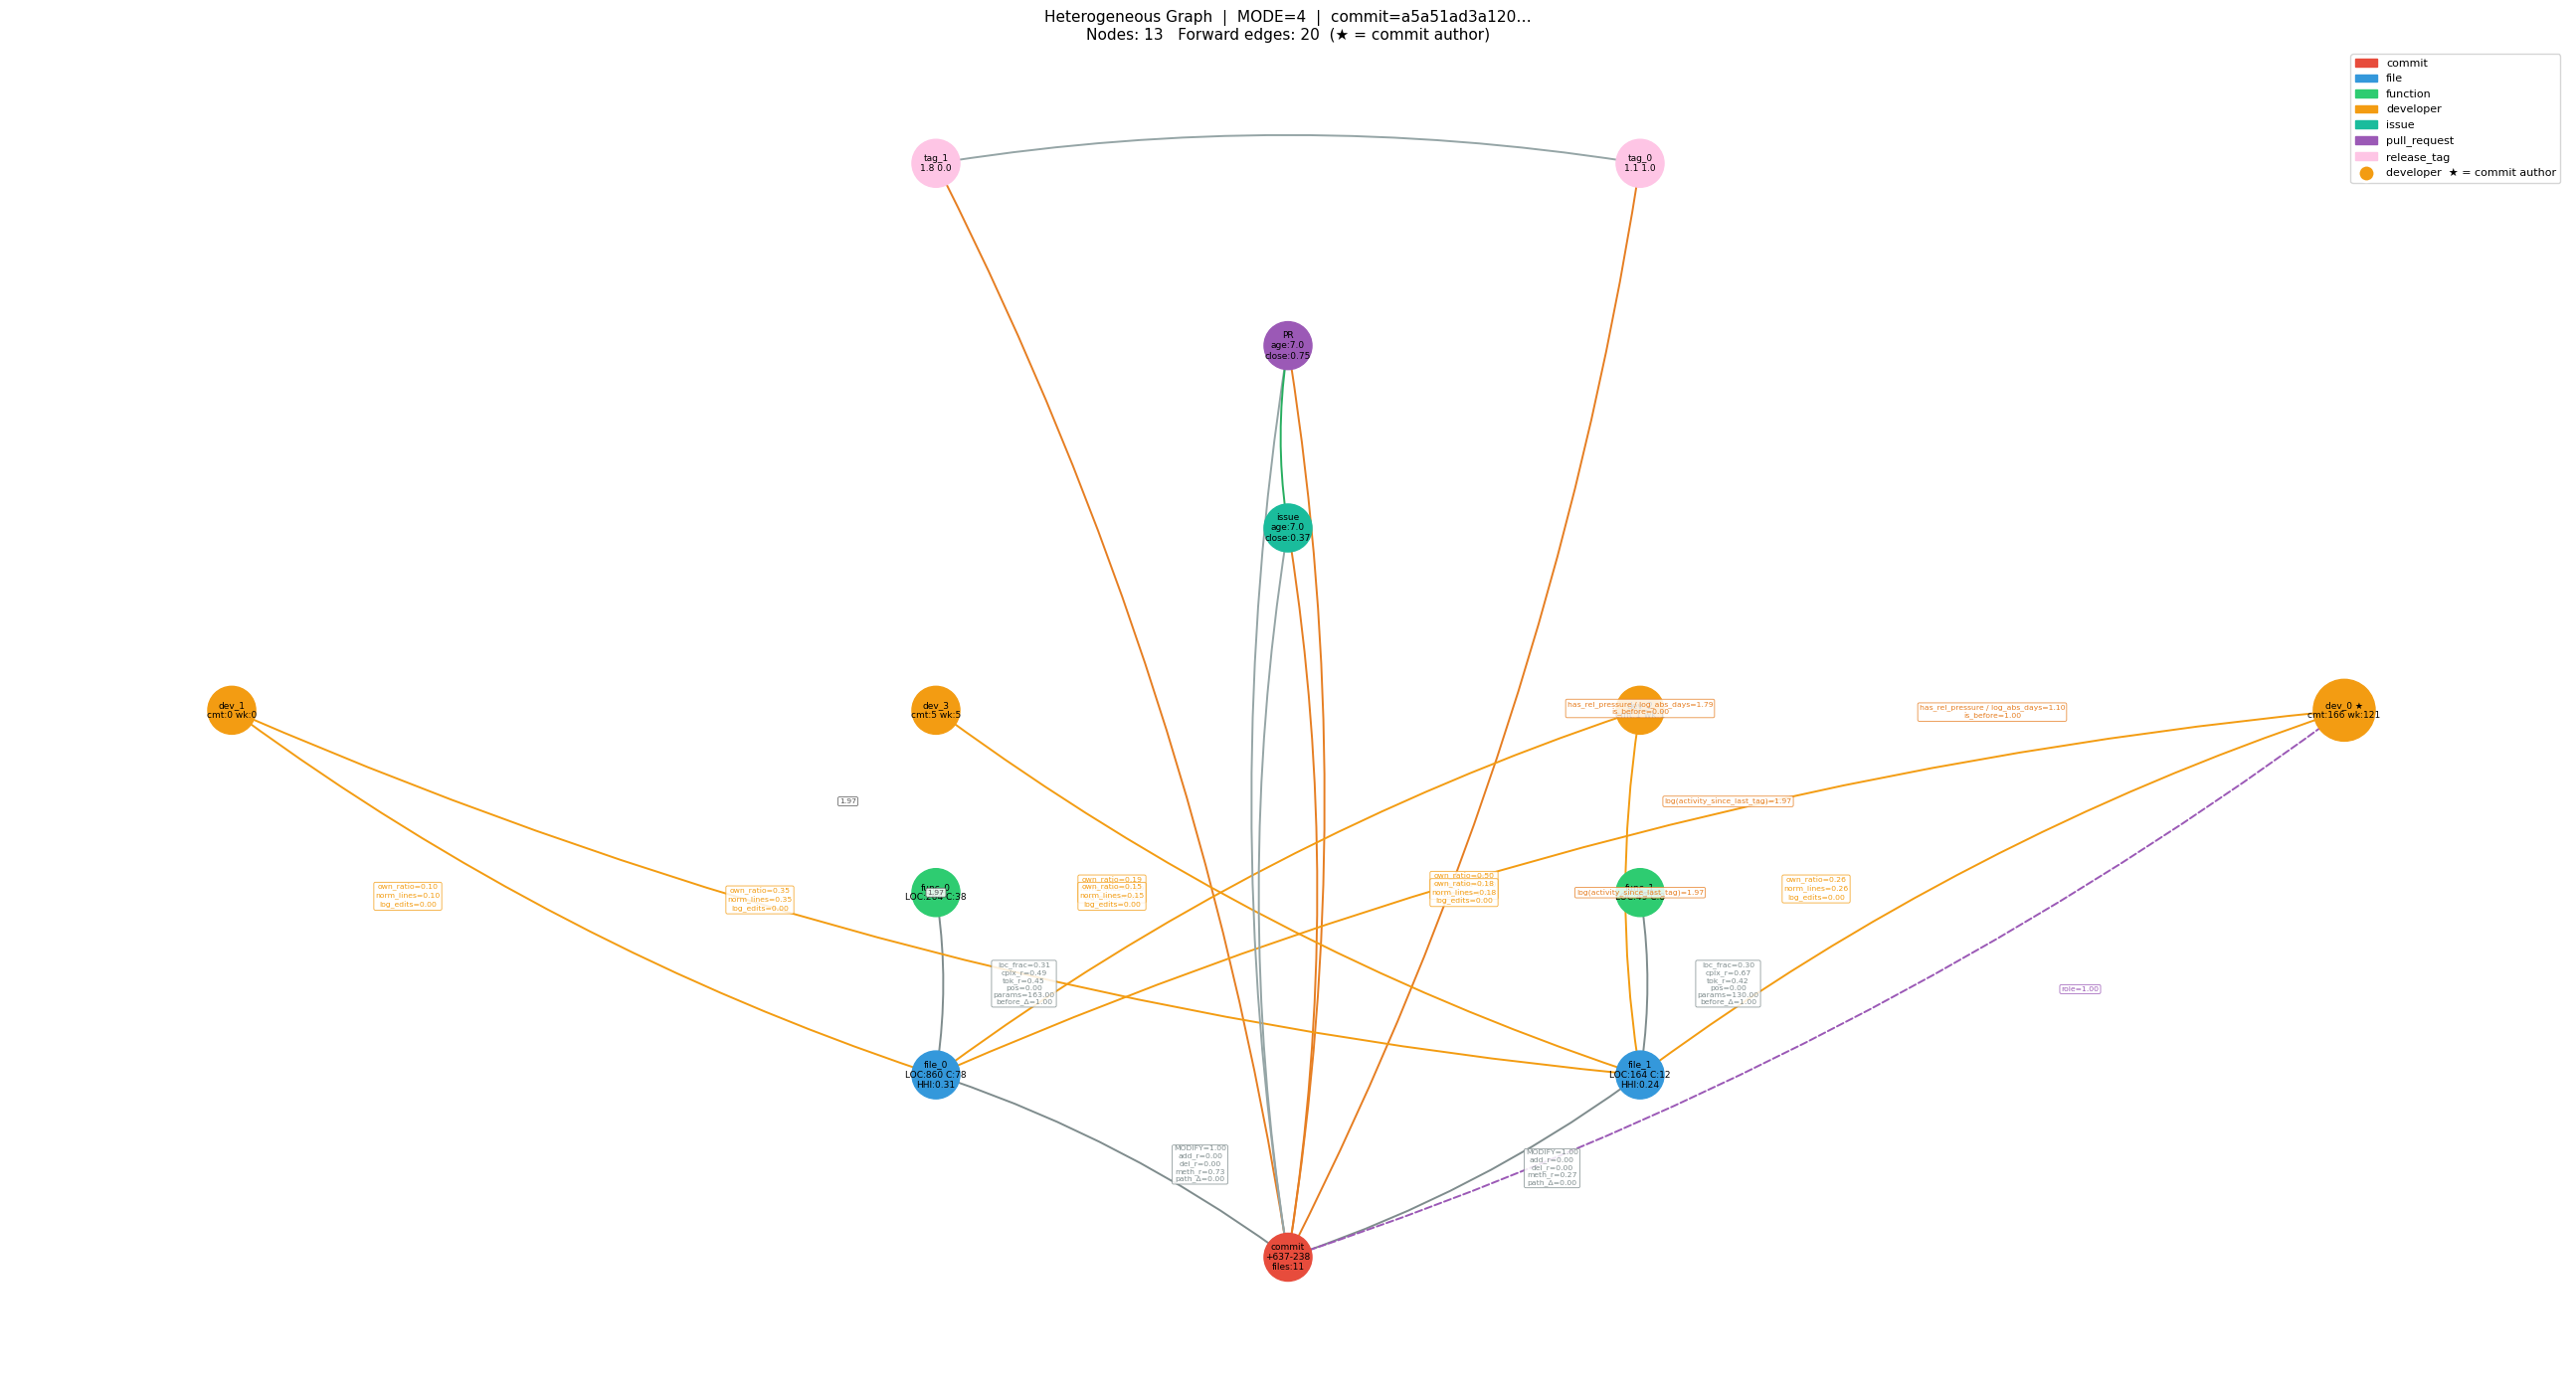

In [5]:
REVERSE_RELS = {'issue_of','pr_of','tag_of','referenced_by_pr','in_release',
                'prev_issue','prev_pr','prev_tag'}

EDGE_ATTR_NAMES = {
    ('commit','has','file')                        : ['ADD','MODIFY','DELETE','RENAME','COPY','UNK',
                                                       'add_r','del_r','meth_r','path_Δ'],
    ('file','has','function')                      : ['loc_frac','cplx_r','tok_r','pos','params','before_Δ'],
    ('function','co_modified','function')          : ['proximity','cplx_sim'],
    ('commit','authored_by','developer')           : ['role'],
    ('developer','owns','file')                    : ['own_ratio','norm_lines','log_edits'],
    ('commit','linked_issue','issue')              : ['log(issue_open_at_anchor)'],
    ('commit','linked_pr','pull_request')          : ['log(pr_count)'],
    ('commit','has_release_tag','release_tag')     : ['has_rel_pressure / log_abs_days','is_before'],
    ('commit','tag_context_pr','pull_request')     : ['log(activity_since_last_tag)'],
    ('commit','tag_context_issue','issue')         : ['log(activity_since_last_tag)'],
    ('pull_request','references_issue','issue')    : ['pr_issue_ratio','pr_issue_gap'],
    ('release_tag','affects_pr','pull_request')    : ['log(activity)'],
    ('release_tag','affects_issue','issue')        : ['log(activity)'],
}

def fmt_edge_attr(et, attr_tensor):
    names = EDGE_ATTR_NAMES.get(et, [])
    vals  = attr_tensor.tolist()
    if not names:
        return ' '.join(f'{v:.2f}' for v in vals)
    parts = [f'{n}={v:.2f}' for n, v in zip(names, vals)
             if not (v == 0.0 and n in ('ADD','MODIFY','DELETE','RENAME','COPY','UNK'))]
    return '\n'.join(parts)

# Developer index → email (for labelling)
dev_idx_to_email = {}
if hasattr(g.get('developer', None), '_email_to_idx'):
    dev_idx_to_email = {v: k for k, v in g['developer']._email_to_idx.items()}
author_dev_idxs = set()
if ('commit','authored_by','developer') in g.edge_types:
    author_dev_idxs = set(g['commit','authored_by','developer'].edge_index[1].tolist())

# ── Build NetworkX graph ──────────────────────────────────────────────
G_vis = nx.DiGraph()

LAYER  = {'commit':0,'file':1,'function':2,'developer':3,
          'issue':4,'pull_request':5,'release_tag':6}
COLOUR = {'commit':'#e74c3c','file':'#3498db','function':'#2ecc71',
          'developer':'#f39c12','issue':'#1abc9c',
          'pull_request':'#9b59b6','release_tag':'#fec5e5'}
EDGE_COLOUR = {
    'has':'#7f8c8d','co_modified':'#e74c3c',
    'authored_by':'#9b59b6','owns':'#f39c12',
    'linked_issue':'#1abc9c','linked_pr':'#8e44ad',
    'has_release_tag':'#e67e22',
    'references_issue':'#27ae60',
    'affects_pr':'#8e44ad','affects_issue':'#1abc9c',
    'next_issue':'#95a5a6','next_pr':'#95a5a6','next_tag':'#95a5a6',
    'tag_context_pr':'#e67e22','tag_context_issue':'#e67e22',
}

def node_label(nt, i, x):
    if nt == 'commit':
        return f'commit\n+{int(x[1])}-{int(x[0])}\nfiles:{int(x[3])}'
    if nt == 'file':
        return f'file_{i}\nLOC:{int(x[3])} C:{int(x[4])}\nHHI:{x[7]:.2f}'
    if nt == 'function':
        return f'func_{i}\nLOC:{int(x[0])} C:{int(x[1])}'
    if nt == 'developer':
        email = dev_idx_to_email.get(i, f'dev_{i}')
        mark  = ' ★' if i in author_dev_idxs else ''
        return f'{email.split("@")[0]}{mark}\ncmt:{np.expm1(x[0]):.0f} wk:{np.expm1(x[1]):.0f}'
    if nt == 'issue':
        return f'issue\nage:{x[0]:.1f}\nclose:{x[1]:.2f}' if x.shape[0] >= 2 else f'issue_{i}'
    if nt == 'pull_request':
        return f'PR\nage:{x[0]:.1f}\nclose:{x[1]:.2f}' if x.shape[0] >= 2 else f'PR_{i}'
    if nt == 'release_tag':
        return f'tag_{i}\n{" ".join(f"{v:.1f}" for v in x[:3])}'
    return f'{nt}_{i}'

for nt in g.node_types:
    for i in range(g[nt].x.shape[0]):
        lbl = node_label(nt, i, g[nt].x[i].numpy())
        G_vis.add_node(f'{nt}_{i}', node_type=nt, layer=LAYER.get(nt,7), label=lbl)

for et in g.edge_types:
    src_t, rel, dst_t = et
    if rel in REVERSE_RELS:
        continue
    ei = g[et].edge_index
    ea = g[et].get('edge_attr')
    for k in range(ei.shape[1]):
        s, d = ei[0,k].item(), ei[1,k].item()
        attr_lbl = fmt_edge_attr(et, ea[k]) if ea is not None else ''
        G_vis.add_edge(f'{src_t}_{s}', f'{dst_t}_{d}',
                       etype=rel, attr_label=attr_lbl,
                       weight=float(ea[k,0]) if ea is not None else 1.0)

# ── Layout ────────────────────────────────────────────────────────────
pos = nx.multipartite_layout(G_vis, subset_key='layer', scale=3, align='horizontal')
for n in G_vis.nodes:
    x, y = pos[n]; pos[n] = (x, y * 2.5)

node_colours = [COLOUR.get(G_vis.nodes[n]['node_type'], '#bdc3c7') for n in G_vis.nodes]
node_sizes   = [2000 if (G_vis.nodes[n]['node_type'] == 'developer' and
                          int(n.split('_')[-1]) in author_dev_idxs) else 1200
                for n in G_vis.nodes]

fig, ax = plt.subplots(figsize=(26, 14))

edge_groups: dict = {}
for u, v, d in G_vis.edges(data=True):
    edge_groups.setdefault(d['etype'], []).append((u, v))
for rel, edges in edge_groups.items():
    col   = EDGE_COLOUR.get(rel, '#95a5a6')
    style = 'dashed' if rel in ('co_modified','authored_by') else 'solid'
    nx.draw_networkx_edges(G_vis, pos, edgelist=edges, edge_color=col,
                           style=style, arrows=True, arrowsize=14, width=1.4,
                           connectionstyle='arc3,rad=0.08', ax=ax)

nx.draw_networkx_nodes(G_vis, pos, node_color=node_colours, node_size=node_sizes, ax=ax)
nx.draw_networkx_labels(G_vis, pos, labels={n: G_vis.nodes[n]['label'] for n in G_vis.nodes},
                        font_size=6.5, ax=ax)

for u, v, d in G_vis.edges(data=True):
    lbl = d.get('attr_label', '')
    if not lbl: continue
    xu, yu = pos[u]; xv, yv = pos[v]
    xm = (xu+xv)/2 + (yv-yu)*0.05
    ym = (yu+yv)/2 + (xu-xv)*0.05
    col = EDGE_COLOUR.get(d['etype'], '#555555')
    ax.text(xm, ym, lbl, fontsize=5.5, ha='center', va='center', color=col,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=col, alpha=0.85, lw=0.6))

legend = [mpatches.Patch(color=c, label=nt) for nt, c in COLOUR.items()
          if any(G_vis.nodes[n]['node_type'] == nt for n in G_vis.nodes)]
legend.append(plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#f39c12',
                          markersize=12, markeredgewidth=2,
                          label='developer  ★ = commit author'))
ax.legend(handles=legend, loc='upper right', fontsize=8)
ax.set_title(
    f'Heterogeneous Graph  |  MODE={MODE}  |  commit={target_hash[:12]}…\n'
    f'Nodes: {G_vis.number_of_nodes()}   Forward edges: {G_vis.number_of_edges()}'
    f'  (★ = commit author)',
    fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()


In [6]:
# ── Print edge attribute details ─────────────────────────────────────
print(f'Edge attributes present in MODE {MODE}:')
for et in g.edge_types:
    ea = g[et].get('edge_attr')
    if ea is not None and ea.shape[0] > 0:
        print(f'  {str(et):55s}  shape={tuple(ea.shape)}')
        print(f'    min={ea.min():.4f}  max={ea.max():.4f}  mean={ea.float().mean():.4f}')


Edge attributes present in MODE 4:
  ('commit', 'has', 'file')                                shape=(2, 10)
    min=0.0000  max=1.0000  mean=0.1500
  ('file', 'has', 'function')                              shape=(2, 6)
    min=0.0000  max=163.0000  mean=24.8025
  ('commit', 'authored_by', 'developer')                   shape=(1, 1)
    min=1.0000  max=1.0000  mean=1.0000
  ('developer', 'owns', 'file')                            shape=(7, 3)
    min=0.0000  max=1.3863  mean=0.2301
  ('commit', 'has_release_tag', 'release_tag')             shape=(2, 2)
    min=0.0000  max=1.7918  mean=0.9726
  ('release_tag', 'tag_of', 'commit')                      shape=(2, 2)
    min=0.0000  max=1.7918  mean=0.9726
  ('commit', 'tag_context_pr', 'pull_request')             shape=(1, 1)
    min=1.9731  max=1.9731  mean=1.9731
  ('pull_request', 'tag_context_of', 'commit')             shape=(1, 1)
    min=1.9731  max=1.9731  mean=1.9731
  ('commit', 'tag_context_issue', 'issue')                 shape=

In [7]:
# ══════════════════════════════════════════════════════════════════════
# Example: build graph manually using individual component functions
# (useful for debugging or adding custom logic between steps)
# ══════════════════════════════════════════════════════════════════════
from torch_geometric.data import HeteroData

commit_row = tables['commit_info'][tables['commit_info']['hash'] == target_hash].reset_index(drop=True)
files      = tables['file_info'][tables['file_info']['hash'] == target_hash].reset_index(drop=True)
funcs      = tables['function_info'][tables['function_info']['hash'] == target_hash].reset_index(drop=True)

g2 = HeteroData()

# Add only the components you want
add_commit_node(g2, commit_row)
add_file_nodes(g2, files, tables['ownership_window'], tables['commit_author'],
               target_hash, OWNERSHIP_WINDOW_DAYS)
add_function_nodes(g2, funcs)
add_developer_nodes(g2, target_hash, files, tables['ownership_window'],
                    tables['developer_info'], tables['commit_author'],
                    OWNERSHIP_WINDOW_DAYS, OWNERSHIP_THRESHOLD)

add_commit_file_edges(g2, commit_row, files)
add_file_function_edges(g2, files, funcs)
add_function_comod_edges(g2, files, funcs)
add_developer_edges(g2, target_hash, files, tables['ownership_window'],
                    tables['commit_author'], OWNERSHIP_WINDOW_DAYS, OWNERSHIP_THRESHOLD)

print('Manual build (commit + file + function + developer only):')
print(g2)


Manual build (commit + file + function + developer only):
HeteroData(
  commit={ x=[1, 7] },
  file={ x=[2, 10] },
  function={ x=[2, 5] },
  developer={ x=[4, 4] },
  (commit, has, file)={
    edge_index=[2, 2],
    edge_attr=[2, 10],
  },
  (file, has, function)={
    edge_index=[2, 2],
    edge_attr=[2, 6],
  },
  (function, co_modified, function)={
    edge_index=[2, 0],
    edge_attr=[0, 2],
  },
  (commit, authored_by, developer)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (developer, owns, file)={
    edge_index=[2, 7],
    edge_attr=[7, 3],
  }
)
